In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation

ImportError: cannot load module more than once per process

In [3]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 153 * 10**5 # In timesteps of dt
gridpoints = 64 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 9E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2= 1.0 / (dx * dx)

#Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
B2 = 2190 # Units: nm^3
vb = 1.66 # Units: nm^3
kB = 1.314E-23*0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84*np.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 #Number of saved values

Da = vb * np.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

NameError: name 'np' is not defined

In [3]:
# Initializes array of density values
np.random.seed(7) # Opens a random number generator instance, seed 7


rho = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=gridpoints)) # Creates rho values around the mean with slight randomness
rho = np.maximum(rho, 1.E-10)  # Prevents negative densities

initial_mass = np.sum(rho)

@jit(nopython=True, cache = True)
def laplacian_1d(function_array):
    """
    Computes the 1D Laplacian of a function, given an array representing that function
    """
    return (np.roll(function_array, -1) - 2*function_array + np.roll(function_array, 1)) * inv_dx2

    # Note: I used 'roll' so it would have periodic boundary conditions

@jit(nopython=True,  cache = True) # Converts the given function into machine code (optimization)
def compute_step_single(rho):

    # Total chemical potential (with floored rho, Xa)
    beta_mu_total = (2.0 * B2 * rho + np.log(rho) + #beta mu_ref
                    valence * np.log((-1 + np.sqrt(1 + 4 * 4*rho*Da)) / (2 * 4*rho*Da)) - #beta mu_b
                    K * (np.roll(rho, -1) - 2.0 * rho + np.roll(rho, 1)) * inv_dx2) #beta mu_int

    # Finds the 1D Laplacian of beta mu total
    laplacian_1d_mu = (np.roll(beta_mu_total, -1) - 2*beta_mu_total + np.roll(beta_mu_total, 1)) * inv_dx2

    # Updates the density explicitly: rho(t+dt) = rho(t) + dt * M laplacian (beta mu_total)
    return  dt * M * laplacian_1d_mu

    
# Initializes arrays for saving rho 
num_saves = duration // save_interval + 1
rho_total_array = np.zeros((num_saves, gridpoints))
rho_total_array[0] = rho
save_index = 1

# Tracks the mass over time to ensure conservation
mass_history = []
time_history = []


for step in range(duration):

    # Iterates to find new value of rho
    rho += compute_step_single(rho)

    # Adds the new density to the array of densities + checks mass conservation every 10^6 steps
    if step % (save_interval) == 0:
        rho_total_array[save_index] = rho
        save_index += 1
    
        total_mass = np.sum(rho) 
    
        mass_history.append(total_mass)
        time_history.append(step * dt)

        rho = np.maximum(rho, floor)

        print(f"Progress: {(step/(save_interval))} out of {duration/(save_interval)}")

"""
OLD FUNCTION; CLEARER TO READ BUT LESS OPTIMIZED
def compute_step_single(rho):

    # Eliminates zeros/negatives
    rho_floored = np.maximum(rho, floor)

    # Finds the 1D Laplacian of rho
    laplacian_1d_rho = (np.roll(rho_floored, -1) - 2.0 * rho_floored + np.roll(rho_floored, 1)) * inv_dx2

    # Initializes Xa
    CaDa = 4*rho_floored*Da
    Xa = (-1 + np.sqrt(1 + 4 * CaDa)) / (2 * CaDa)

    # Total chemical potential (with floored rho, Xa)
    beta_mu_total = (2.0 * B2 * rho_floored + np.log(rho_floored) + #beta mu_ref
                    valence * np.log(Xa) - #beta mu_b
                    K * laplacian_1d_rho) #beta mu_int

    # Finds the 1D Laplacian of beta mu total
    laplacian_1d_mu = (np.roll(beta_mu_total, -1) - 2*beta_mu_total + np.roll(beta_mu_total, 1)) * inv_dx2

    # Updates the density explicitly: rho(t+dt) = rho(t) + dt * M laplacian (beta mu_total)
    return  dt * M * laplacian_1d_mu

"""

Progress: 0.0 out of 100.0
Progress: 1.0 out of 100.0
Progress: 2.0 out of 100.0
Progress: 3.0 out of 100.0
Progress: 4.0 out of 100.0
Progress: 5.0 out of 100.0
Progress: 6.0 out of 100.0
Progress: 7.0 out of 100.0
Progress: 8.0 out of 100.0
Progress: 9.0 out of 100.0
Progress: 10.0 out of 100.0
Progress: 11.0 out of 100.0
Progress: 12.0 out of 100.0
Progress: 13.0 out of 100.0
Progress: 14.0 out of 100.0
Progress: 15.0 out of 100.0
Progress: 16.0 out of 100.0
Progress: 17.0 out of 100.0
Progress: 18.0 out of 100.0
Progress: 19.0 out of 100.0
Progress: 20.0 out of 100.0
Progress: 21.0 out of 100.0
Progress: 22.0 out of 100.0
Progress: 23.0 out of 100.0
Progress: 24.0 out of 100.0
Progress: 25.0 out of 100.0
Progress: 26.0 out of 100.0
Progress: 27.0 out of 100.0
Progress: 28.0 out of 100.0
Progress: 29.0 out of 100.0
Progress: 30.0 out of 100.0
Progress: 31.0 out of 100.0
Progress: 32.0 out of 100.0
Progress: 33.0 out of 100.0
Progress: 34.0 out of 100.0
Progress: 35.0 out of 100.0
Pr

'\nOLD FUNCTION; CLEARER TO READ BUT LESS OPTIMIZED\ndef compute_step_single(rho):\n\n    # Eliminates zeros/negatives\n    rho_floored = np.maximum(rho, floor)\n\n    # Finds the 1D Laplacian of rho\n    laplacian_1d_rho = (np.roll(rho_floored, -1) - 2.0 * rho_floored + np.roll(rho_floored, 1)) * inv_dx2\n\n    # Initializes Xa\n    CaDa = 4*rho_floored*Da\n    Xa = (-1 + np.sqrt(1 + 4 * CaDa)) / (2 * CaDa)\n\n    # Total chemical potential (with floored rho, Xa)\n    beta_mu_total = (2.0 * B2 * rho_floored + np.log(rho_floored) + #beta mu_ref\n                    valence * np.log(Xa) - #beta mu_b\n                    K * laplacian_1d_rho) #beta mu_int\n\n    # Finds the 1D Laplacian of beta mu total\n    laplacian_1d_mu = (np.roll(beta_mu_total, -1) - 2*beta_mu_total + np.roll(beta_mu_total, 1)) * inv_dx2\n\n    # Updates the density explicitly: rho(t+dt) = rho(t) + dt * M laplacian (beta mu_total)\n    return  dt * M * laplacian_1d_mu\n\n'

In [4]:
# Checks Mass Conservation

# Adjusts final array to a 0-255 scale where min --> 0 and max --> 255
rho_maximum = np.max(rho_total_array)
rho_minimum = np.min(rho_total_array)

# Creates a B&W image using the adjusted array
rho_img_singlecomponent_uniform = 255- (255 * (rho_total_array - rho_minimum) / 
           (rho_maximum - rho_minimum)).astype(np.uint8)
img_singlecomponent_uniform = Image.fromarray(rho_img_singlecomponent_uniform, 'L')

#Checks mass conservation over time
maximum_mass_singlecomponent_uniform = np.max(mass_history)
minimum_mass_singlecomponent_uniform = np.min(mass_history)
if (maximum_mass_singlecomponent_uniform - minimum_mass_singlecomponent_uniform) > 1E-10:
    print("WARNING: MASS MAY NOT BE CONSERVED!!")
    plt.figure()
    plt.plot(time_history, mass_history, label="Total Mass", color = "mediumseagreen")
    plt.xlabel("Time (s)")
    plt.ylabel("Mass")
    plt.title("Mass Conservation Check")
    plt.legend()
    plt.show()

In [5]:
# Finds Surface Tension

# Loads Spinodal Data
spinodal_data = np.loadtxt(f"spinodals/f{valence:.1f}")
idx_spinodal = np.argmin(np.abs(spinodal_data[:,0] - T))
rho_spinodal_low  = spinodal_data[idx_spinodal, 1]
rho_spinodal_high = spinodal_data[idx_spinodal, 2]


def calc_free_energy(rho, Xa, v0 = 1):
    '''
    Finds free energy of a system using F = integral_V [ f({rho_i}) + K/2 sum_i (gradient rho)^2 ] dV

    Using f_ref = rho * log(v_0 * rho) - rho + B2 * rho^2 + {sum_i [rho_i log(rho_i/rho_tot)]}

    The last term will always be 0 for a 1-component system (log 1 = 0), so it not included here

    Using f_b = rho_A * valence * (log(Xa) + (1-Xa)/2)
    
    Note that this will vary by mixture-- eq shown is for AAAA only
    '''

    # Floors rho to prevent error
    rho_floored = np.maximum(rho, floor)

    # Finds f_ref and f_b
    f_ref = rho_floored * np.log(v0 * rho_floored) - rho_floored + B2 * rho_floored**2
    f_b = rho_floored * 4 * (np.log(Xa) + (1-Xa)/2)

    # Finds the local free energy at each point (f{rho_i})
    f_local = f_ref + f_b
    
    # Calculates the gradient term K/2 * (gradient rho)^2
    f_gradient = 0.5 * K * (np.gradient(rho_floored, dx))**2
    
    # Total free energy density
    f_total = f_local + f_gradient
    
    # Integrate over volume in 1D (multiply by dx and sum)
    F_total = np.trapz(f_total, dx=dx)
    
    return F_total


#Takes floored value for rho and finds area of interface for final system
rho_floored = np.maximum(rho, floor)
A = dx ** 2

# Extracts dilute/dense phase densities and creates homogenous systems
rho_dilute = np.min(rho_floored) 
rho_dense = np.max(rho_floored)

rho_dilute_system = np.full(gridpoints, rho_dilute)
rho_dense_system = np.full(gridpoints, rho_dense)

# Finds Xa for dilute, dense, and coex
CaDa = 4*rho_floored*Da
Xa = (-1 + np.sqrt(1 + 4 * CaDa)) / (2 * CaDa)
Xa_final_coex = np.maximum(Xa, floor) 

CaDa_dilute = 4*rho_dilute_system*Da
CaDa_dilute_floored = np.maximum(CaDa_dilute, floor)
Xa_final_dilute = (-1 + np.sqrt(1 + 4 * CaDa_dilute_floored)) / (2 * CaDa_dilute_floored)

CaDa_dense = 4*rho_dense_system*Da
CaDa_dense_floored = np.maximum(CaDa_dense, floor)
Xa_final_dense = (-1 + np.sqrt(1 + 4 * CaDa_dense_floored)) / (2 * CaDa_dense_floored)

# Finds free energy of dilute, dense, and coexisting systems
F_dilute = calc_free_energy(rho_dilute_system, Xa_final_dilute)
F_dense = calc_free_energy(rho_dense_system, Xa_final_dense)
F_coex = calc_free_energy(rho_floored, Xa_final_coex)


phase_id = np.zeros_like(rho_floored, dtype=int)
phase_id[rho_floored < rho_spinodal_low]  = 0   # dilute
phase_id[rho_floored > rho_spinodal_high] = 1   # dense
phase_id[(rho_floored >= rho_spinodal_low) & (rho_floored <= rho_spinodal_high)] = -1  # interface

interface_locations = np.where(np.diff(phase_id) != 0)[0]
interface_count = len(interface_locations)

surface_tension = (F_coex - F_dilute - F_dense) / (interface_count * A)
print(f"The surface tension is {surface_tension:.6e} for T = {T} in a 1D system with {interface_count} interfaces and 1 component, initialized with a uniform distribution")

The surface tension is 1.461467e-03 for T = 303.15 in a 1D system with 8 interfaces and 1 component, initialized with a uniform distribution


In [6]:
# Checks phase densities against those predicted by SPINODAL (INCORRECT)

'''
spinodal_data = np.loadtxt(f"spinodals/f{valence:.1f}")
idx = np.argmin(np.abs(spinodal_data.T[0] - T))
dilute = spinodal_data[idx, 1]
dense = spinodal_data[idx, 2]
print(f"For a temperature of {T}:")
print(f"The predicted dilute phase density using the SPINODAL is {dilute:.3} and the actual dilute phase density is {min(rho):.3e}")
print(f"The predicted dense phase density using the SPINODAL is {dense:.3e} and the actual dense phase density is {max(rho):.3e}")
'''

'\nspinodal_data = np.loadtxt(f"spinodals/f{valence:.1f}")\nidx = np.argmin(np.abs(spinodal_data.T[0] - T))\ndilute = spinodal_data[idx, 1]\ndense = spinodal_data[idx, 2]\nprint(f"For a temperature of {T}:")\nprint(f"The predicted dilute phase density using the SPINODAL is {dilute:.3} and the actual dilute phase density is {min(rho):.3e}")\nprint(f"The predicted dense phase density using the SPINODAL is {dense:.3e} and the actual dense phase density is {max(rho):.3e}")\n'

In [7]:
# Checks phase densities against those predicted by BINODAL??

binodal_data = np.loadtxt(f"binodals/f{valence:.1f}")
idx_b = np.argmin(np.abs(binodal_data.T[0] - T))
dilute_b = binodal_data[idx_b, 1]
dense_b = binodal_data[idx_b, 2]
print(f"For a temperature of {T}:")
print(f"The predicted dilute phase density using the binodal is {dilute_b:.3} and the actual dilute phase density is {min(rho):.3e}")
print(f"The predicted dense phase density using the binodal is {dense_b:.3e} and the actual dense phase density is {max(rho):.3e}")

For a temperature of 303.15:
The predicted dilute phase density using the binodal is 4.31e-06 and the actual dilute phase density is 4.335e-06
The predicted dense phase density using the binodal is 2.550e-04 and the actual dense phase density is 2.281e-04


In [8]:
# Lever Rule Compliance
binodal_data = np.loadtxt(f"binodals/f{valence:.1f}")
spinodal_data = np.loadtxt(f"spinodals/f{valence:.1f}")

idx_binodal  = np.argmin(np.abs(binodal_data[:,0]  - T))
idx_spinodal = np.argmin(np.abs(spinodal_data[:,0] - T))

dilute_binodal = binodal_data[idx_binodal, 1]
dense_binodal  = binodal_data[idx_binodal, 2]

dilute_spinodal  = spinodal_data[idx_spinodal, 1]
dense_spinodal = spinodal_data[idx_spinodal, 2]


expected_phase_fraction_dense = ((rho_mean - dilute_binodal)/(dense_binodal - dilute_binodal))
expected_phase_fraction_dilute = ((rho_mean - dense_binodal)/(dilute_binodal - dense_binodal))

actual_phase_number_dense = 0
actual_phase_number_dilute = 0

#Ignores interface region
for point in rho:
    if point < dilute_spinodal:
        actual_phase_number_dilute += 1
    elif point > dense_spinodal:
        actual_phase_number_dense += 1
    else:
        pass

actual_phase_fraction_dense = actual_phase_number_dense/(actual_phase_number_dense + actual_phase_number_dilute)
actual_phase_fraction_dilute = actual_phase_number_dilute/(actual_phase_number_dense + actual_phase_number_dilute)

print(f"The expected phase fraction for the dense phase was {expected_phase_fraction_dense:.3} and the actual phase fraction was {actual_phase_fraction_dense}")
print(f"The expected phase fraction for the dilute phase was {expected_phase_fraction_dilute:.3} and the actual phase fraction was {actual_phase_fraction_dilute}")

The expected phase fraction for the dense phase was 0.342 and the actual phase fraction was 0.44
The expected phase fraction for the dilute phase was 0.658 and the actual phase fraction was 0.56


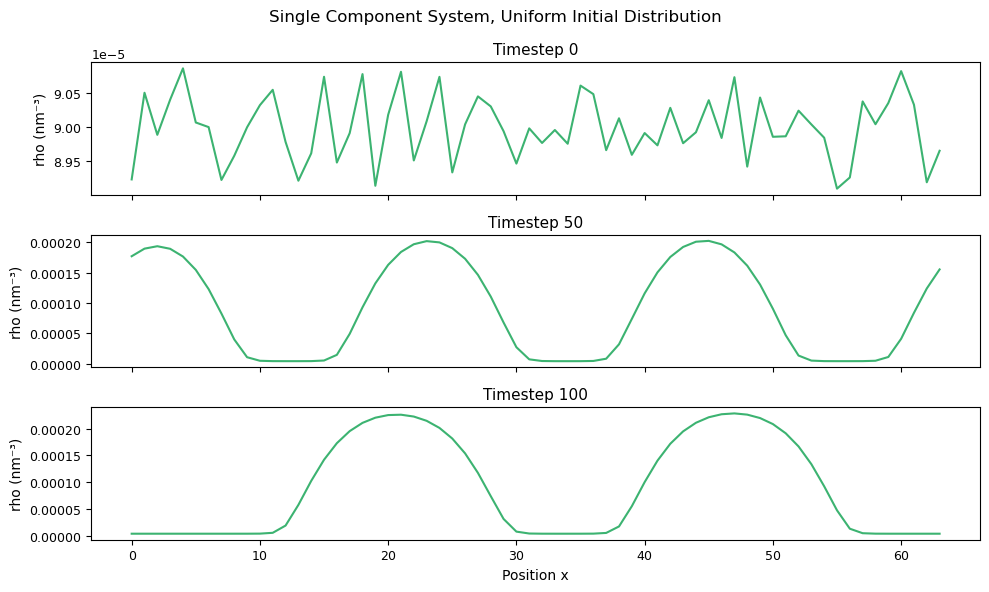

Final mean: 8.999398380745677e-05


In [9]:
# Plots
plt.rcParams.update({
    'font.size': 10,            # general text
    'axes.titlesize': 11,       # subplot titles
    'axes.labelsize': 10,       # x/y labels
    'xtick.labelsize': 9,       # x-axis tick labels
    'ytick.labelsize': 9,       # y-axis tick labels
})

#Initializes x-axis values
x = np.arange(rho_total_array.shape[1])

# Picks evenly spaced timesteps to graph
n_snapshots = 3
timesteps = np.linspace(0, int((duration/(save_interval))), n_snapshots, dtype=int)

# Makes subplots
fig, axes = plt.subplots(n_snapshots, 1, figsize=(10, 2*n_snapshots), sharex=True)

for i, t in enumerate(timesteps):
    ax = axes[i]
    ax.plot(x, rho_total_array[t], color= "mediumseagreen")
    ax.set_ylabel("rho (nm⁻³)")
    ax.set_title(f"Timestep {t}")

axes[-1].set_xlabel("Position x")
fig.suptitle("Single Component System, Uniform Initial Distribution")
plt.tight_layout()
plt.show()

print(f"Final mean: {np.mean(rho)}")



In [10]:
"""
def find_maxima(rho):
    indices_of_maxima = []
    for i in range(1, len(rho)-1):
        if rho[i] > rho[i-1] and rho[i] > rho[i+1]:
            indices_of_maxima.append(i)
    return indices_of_maxima

length = 10

for reps in range(length):
    np.random.seed(reps) # Opens a random number generator instance, seed 7


    rho = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=gridpoints)) # Creates rho values around the mean with slight randomness
    rho = np.maximum(rho, 1.E-10)  # Prevents negative densities

    for step in range(duration):

    # Iterates to find new value of rho
        rho += compute_step_single(rho)

    
    maxes = find_maxima(rho)

    print(f"For seed {reps} peaks are located at {maxes}")
"""

'\ndef find_maxima(rho):\n    indices_of_maxima = []\n    for i in range(1, len(rho)-1):\n        if rho[i] > rho[i-1] and rho[i] > rho[i+1]:\n            indices_of_maxima.append(i)\n    return indices_of_maxima\n\nlength = 10\n\nfor reps in range(length):\n    np.random.seed(reps) # Opens a random number generator instance, seed 7\n\n\n    rho = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=gridpoints)) # Creates rho values around the mean with slight randomness\n    rho = np.maximum(rho, 1.E-10)  # Prevents negative densities\n\n    for step in range(duration):\n\n    # Iterates to find new value of rho\n        rho += compute_step_single(rho)\n\n    \n    maxes = find_maxima(rho)\n\n    print(f"For seed {reps} peaks are located at {maxes}")\n'

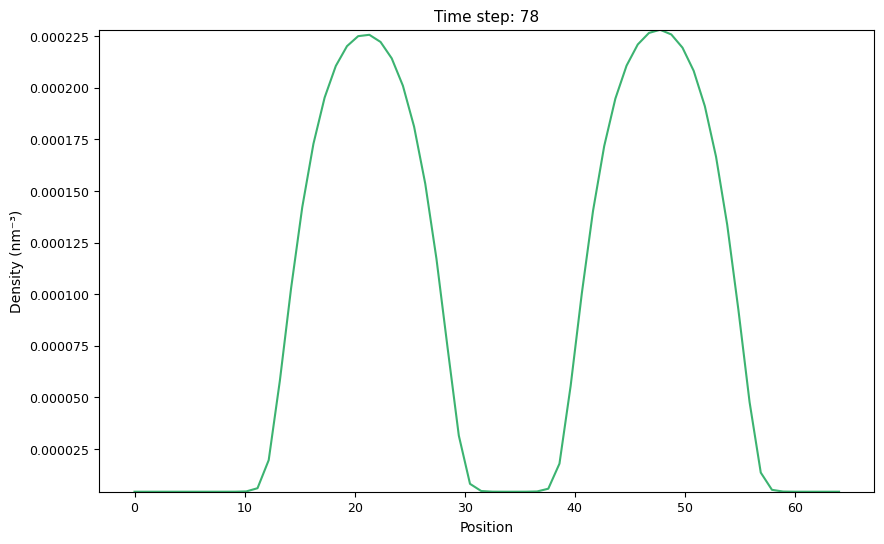

In [11]:
# Plots
plt.rcParams.update({
    'font.size': 10,            # general text
    'axes.titlesize': 11,       # subplot titles
    'axes.labelsize': 10,       # x/y labels
    'xtick.labelsize': 9,       # x-axis tick labels
    'ytick.labelsize': 9,       # y-axis tick labels
})

x = np.linspace(0, gridpoints, gridpoints)

early = np.logspace(0, np.log10(20), 300, dtype=int)

late = np.logspace(np.log10(20), np.log10(200), 100, dtype = int)

timesteps = np.unique(np.concatenate([early, late]))

data_movie_uniform= []

for i, t in enumerate(timesteps):
    if t < rho_total_array.shape[0]:
        data_movie_uniform.append(rho_total_array[t])

fig, ax = plt.subplots(figsize=(10, 2*n_snapshots))

line, = ax.plot(x, data_movie_uniform[0], color= "mediumseagreen")

ax.set_ylim(np.min(data_movie_uniform), np.max(data_movie_uniform))

def update(frame):
    line.set_ydata(data_movie_uniform[frame])
    ax.set_xlabel("Position")
    ax.set_ylabel("Density (nm⁻³)")
    ax.set_title(f'Time step: {frame}')
    return line,

ani = FuncAnimation(fig, update, frames=len(data_movie_uniform), interval=200, blit=True)
ani.save("phase_separation.gif", writer=PillowWriter(fps=7))